{0: 0}


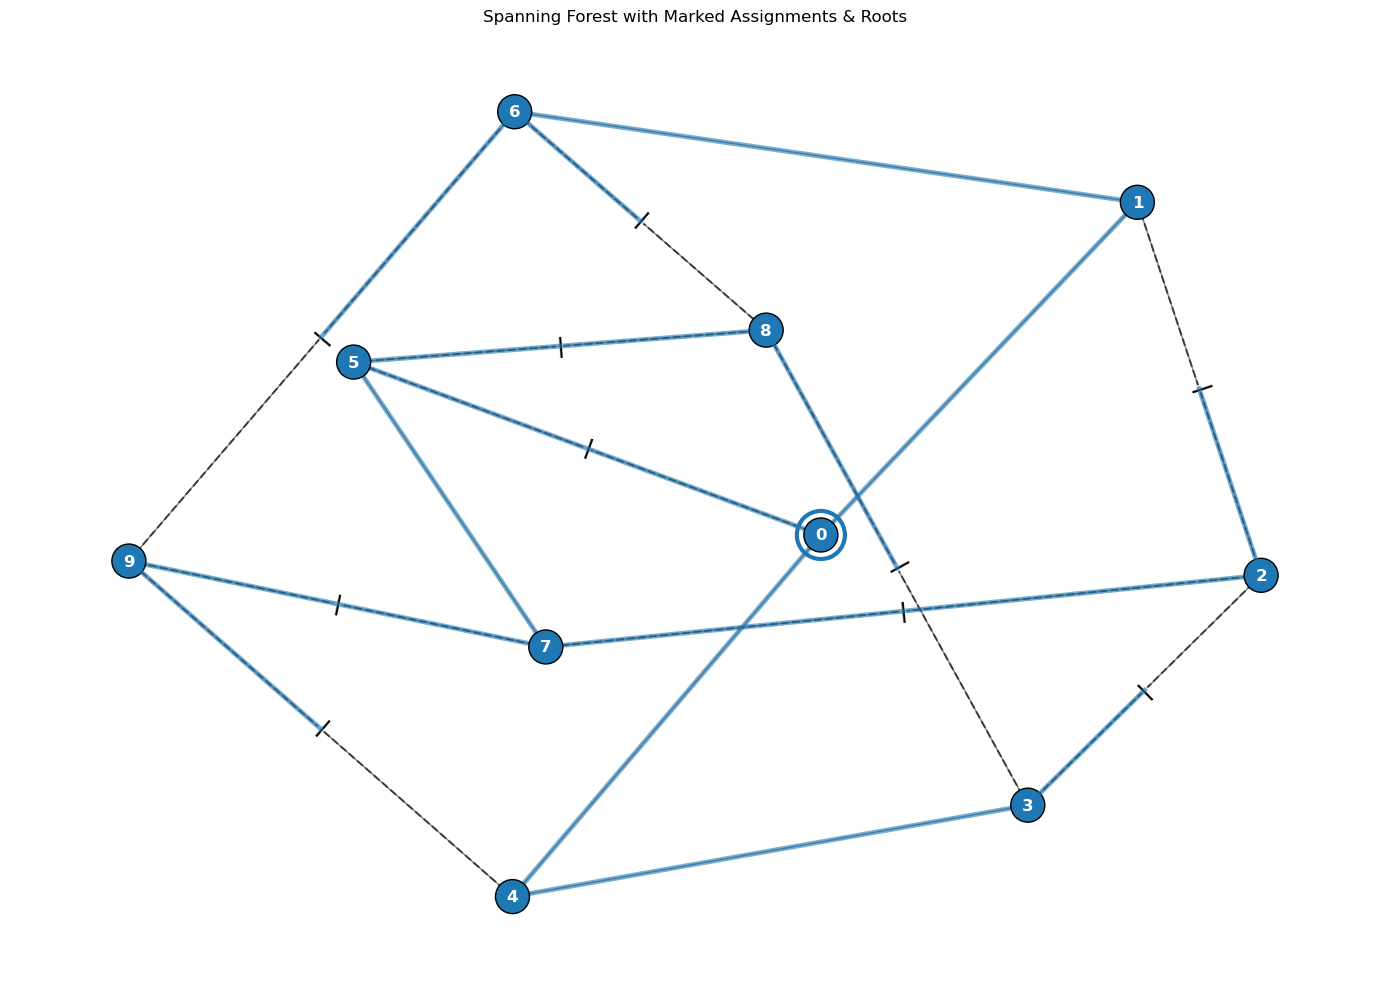

In [6]:
import stim

from spidercat import markings
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet, ed

grf, forest, M, matchings = load_solution_triplet(10, 5, 1)
roots = find_min_height_roots(forest)
print(roots)

matchings = match_forest_leaves_to_marked_edges(grf, forest)
roots = find_min_height_roots(forest)
draw_spanning_forest_solution(grf, forest, M, matchings, roots)
# get_forest_max_diameter(forest)

In [7]:
from spidercat.benchmark import benchmark_solution

og = benchmark_solution(grf, forest, M, matchings, roots, num_samples=5_000_000)

Stats for 10-cat (p=0.05): {0: 0.7819290021544024, 1: 0.1934363944157615, 2: 0.022480200978797285, 3: 0.0019583922835811284, 4: 0.00017777666350809196, 5: 1.8233503949547894e-05}


{1: [(1, 2)], 2: [(2, 7)], 5: [(5, 8)], 6: [(1, 6)], 7: [(5, 7)], 8: [(6, 8)]}


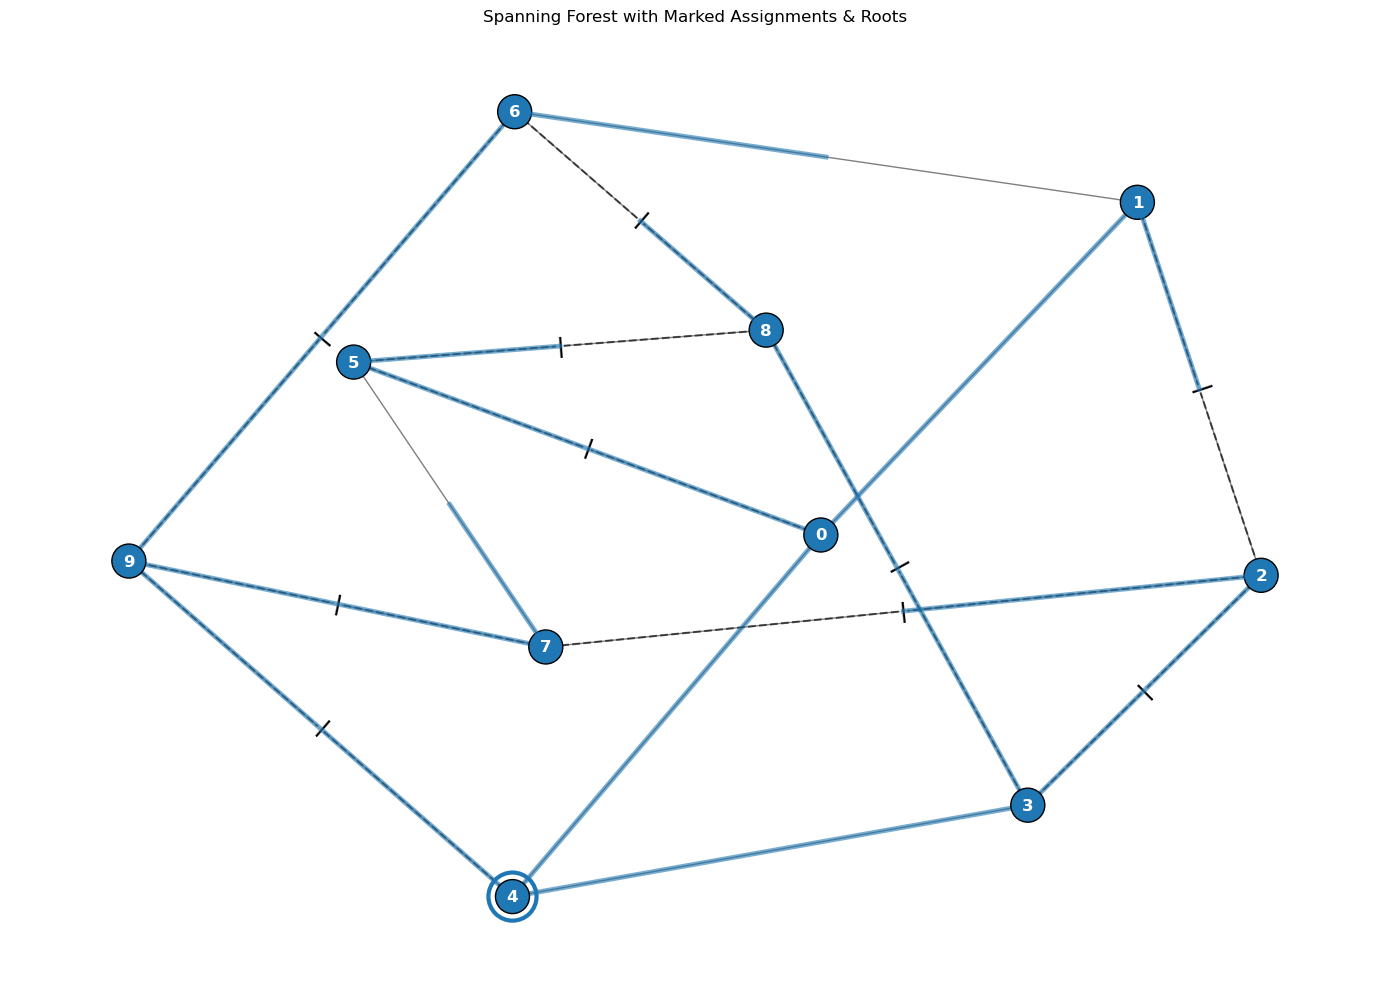

In [8]:
import random
import networkx as nx

def approximate_k_center(G, k, weight='weight', seed=None):
    """
    Finds k approximate centers using Gonzalez's Furthest-First Traversal.
    Returns a list of k center nodes.
    """
    if k <= 0 or k > len(G):
        raise ValueError("k must be between 1 and the number of nodes in G.")

    if seed is not None:
        random.seed(seed)

    # 1. Compute all-pairs shortest path lengths for quick lookups
    dist = dict(nx.all_pairs_dijkstra_path_length(G, weight=weight))

    nodes = list(G.nodes())
    first_center = random.choice(nodes)
    centers = [first_center]

    # Track the minimum distance from each node to the closest chosen center
    min_dist_to_centers = {node: dist[first_center][node] for node in nodes}

    # 2. Greedily pick the remaining k-1 centers
    for _ in range(1, k):
        # Find the node that maximizes the minimum distance to existing centers
        next_center = max(nodes, key=lambda n: min_dist_to_centers[n])
        centers.append(next_center)

        # Update the closest center distances for all nodes
        for node in nodes:
            if dist[next_center][node] < min_dist_to_centers[node]:
                min_dist_to_centers[node] = dist[next_center][node]

    return centers

def k_spanning_forest(G, k, weight='weight', seed=None):
    """
    Generates an approximate Minimum Diameter k-Spanning Forest.
    Returns the forest (nx.Graph) and the list of centers used.
    """
    # 1. Find the k centers
    centers = approximate_k_center(G, k, weight=weight, seed=seed)

    # 2. Grow trees simultaneously from all centers
    # NetworkX's multi_source_dijkstra_path perfectly maps each node
    # to its closest center and returns the shortest path to it.
    paths = nx.multi_source_dijkstra_path(G, centers, weight=weight)

    # 3. Build the forest from the resulting paths
    forest = nx.Graph()
    for node, path in paths.items():
        if len(path) > 1:
            # Add the final edge of the path, preserving original edge attributes
            u, v = path[-2], path[-1]
            edge_data = G.get_edge_data(u, v)
            forest.add_edge(u, v, **edge_data)

    return forest, centers

F, c = k_spanning_forest(grf, 1)
matchings = match_forest_leaves_to_marked_edges(grf, F)
print(matchings)
draw_spanning_forest_solution(grf, F, M, matchings, c)

In [9]:
from spidercat.circuit_extraction import extract_circuit_rooted
from spidercat.benchmark import benchmark_solution

circ = extract_circuit_rooted(grf, F, {i: c for i, c in enumerate(c)}, M, matchings, verbose=True)
new1 = benchmark_solution(grf, F, M, matchings, {i: c for i, c in enumerate(c)}, num_samples=1_000_000)
circ.diagram('timeline-svg')

=== Starting Clean Extraction ===
  Estimated Data Qubits: 10
  Flags start at: 10
Init Root 4 (Tree 0) -> Q0
  Node 4 -> Branch 3 (New Q1)
  Node 3 -> Branch 8 (New Q2)
    Internal Mark (3, 8): Added Q3
    Match Allocation: Node 8 absorbs (6, 8)
    Link (5, 8) (1st visit): Created Flag 10, CNOT 2->10
    Link (6, 8) (1st visit): Created Flag 11, CNOT 2->11
  Node 3 -> Primary 2 (Inherits Q1)
    Internal Mark (2, 3): Added Q4
    Match Allocation: Node 2 absorbs (2, 7)
    Link (1, 2) (1st visit): Created Flag 12, CNOT 1->12
    Link (2, 7) (1st visit): Created Flag 13, CNOT 1->13
  Node 4 -> Branch 9 (New Q5)
    Internal Mark (4, 9): Added Q6
  Node 9 -> Branch 7 (New Q7)
    Internal Mark (7, 9): Added Q8
    Match Allocation: Node 7 absorbs (5, 7)
    Link (2, 7) (2nd visit): Retrieved Flag 13, CNOT Q7->13
    Link (5, 7) (1st visit): Created Flag 14, CNOT 7->14
  Node 9 -> Primary 6 (Inherits Q5)
    Internal Mark (6, 9): Added Q9
    Match Allocation: Node 6 absorbs (1, 6)
  

ValueError: The two qubit gate CX was applied to a target pair with the same target (10) twice. Gates can't interact targets with themselves.

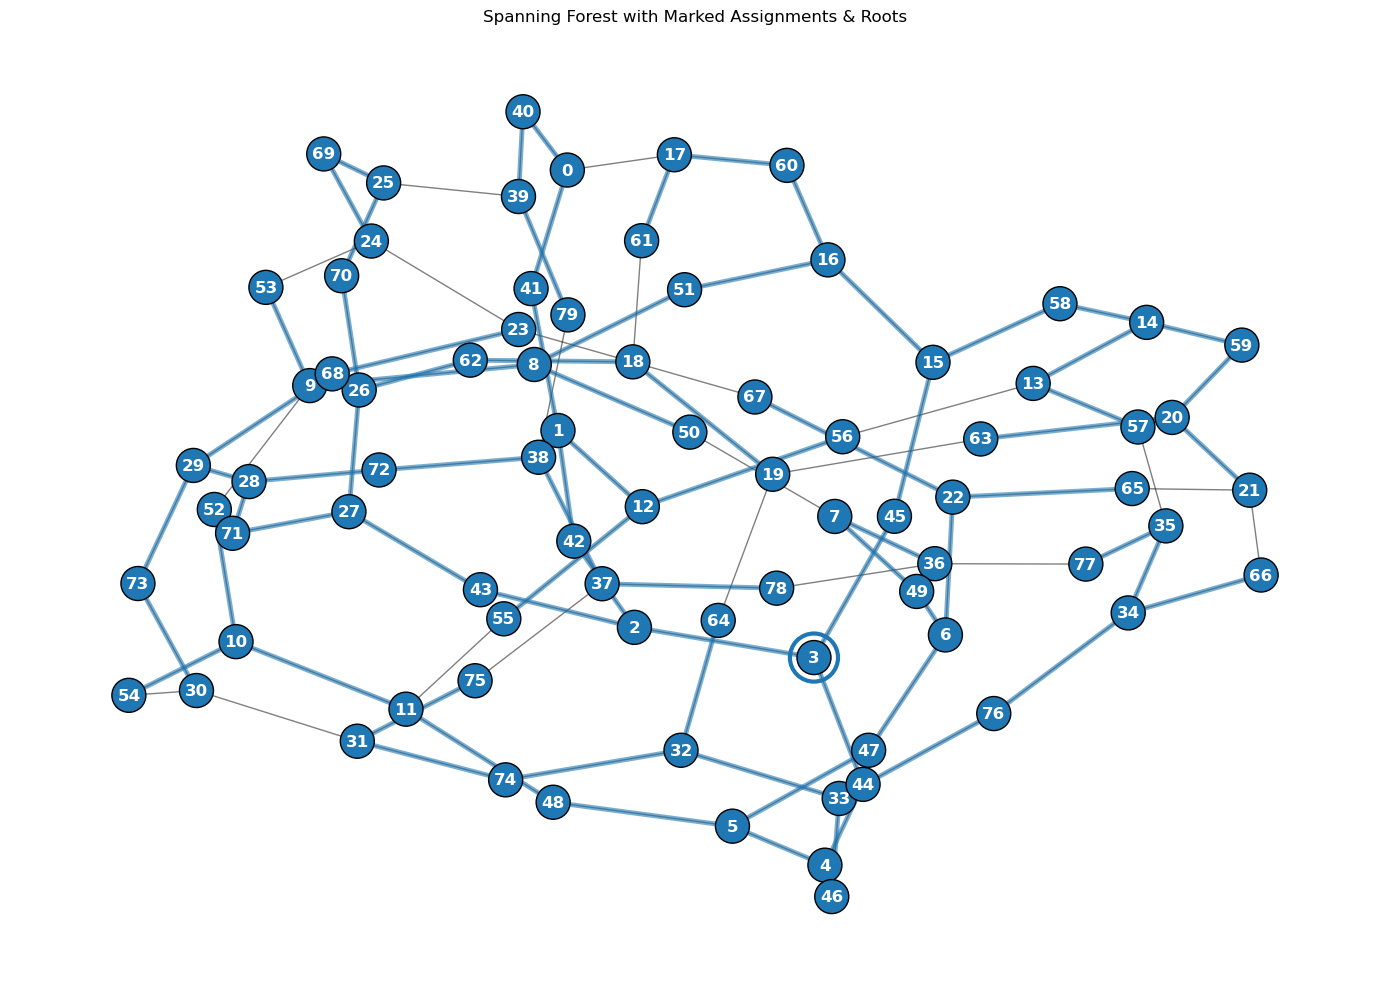

In [12]:
import networkx as nx

def subdivide_edges(G: nx.Graph, markings: dict[tuple[int, int], int]) -> nx.Graph:
    # Create a copy to avoid mutating the original graph
    G_new = G.copy()

    # Find the maximum integer node ID to generate unique IDs for the new nodes
    int_nodes = [n for n in G_new.nodes() if isinstance(n, int)]
    next_node_id = max(int_nodes) + 1 if int_nodes else 0

    for (u, v), k in markings.items():
        # Skip if k is 0 or if the edge doesn't exist in the graph
        if k <= 0 or not G_new.has_edge(u, v):
            continue

        G_new.remove_edge(u, v)

        new_nodes = list(range(next_node_id, next_node_id + k))
        next_node_id += k
        G_new.add_nodes_from(new_nodes)

        # Create the chain: u -> new_node_1 -> ... -> new_node_k -> v
        edges_to_add = []
        prev_node = u
        for current_node in new_nodes:
            edges_to_add.append((prev_node, current_node))
            prev_node = current_node

        edges_to_add.append((prev_node, v))
        G_new.add_edges_from(edges_to_add)

    return G_new

G = subdivide_edges(grf, M)
F, c = k_spanning_forest(G, 1)
draw_spanning_forest_solution(G, F, {}, None, c)

--- Starting Pipeline for k=1 ---
Step 1: Running greedy heuristic for initial state...
Initial Greedy Forest Max Diameter: 19
Step 2: Extracting the matching constraint...
Extracted 21 removed edges.
Step 3: Running Simulated Annealing to optimize...
Optimization finished in 9206 steps. Best Diameter: 19


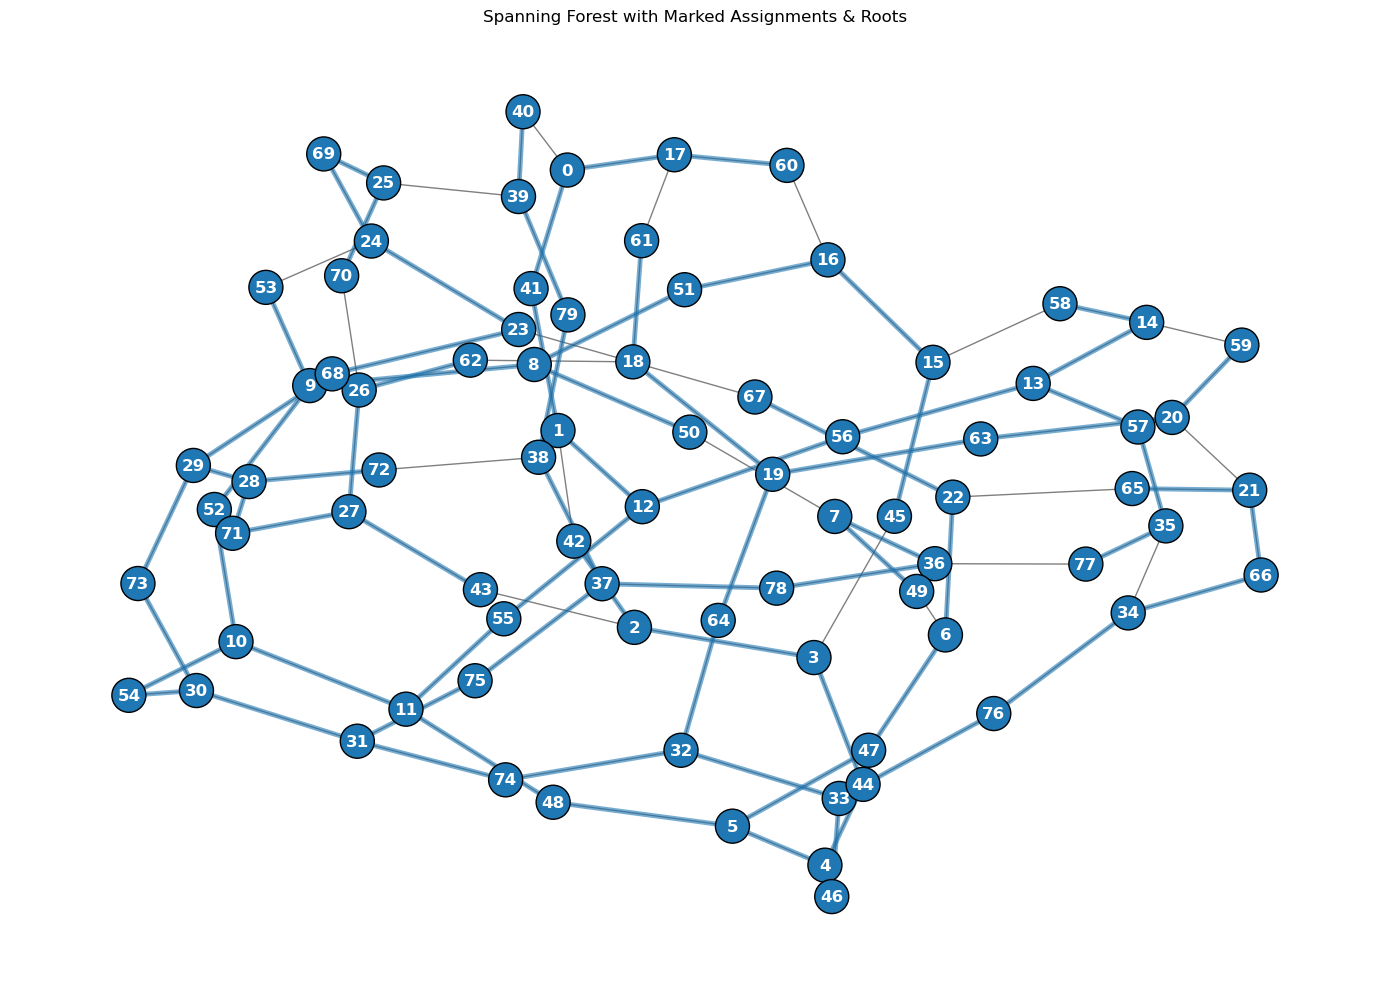

In [14]:
import math
import random
import networkx as nx

import networkx as nx

def constrained_mdsf(G, k, weight='weight'):
    """
    Generates an approximate Minimum Diameter k-Spanning Forest where
    all leaves are guaranteed to be nodes that originally had degree 2.
    """
    # 1. Find k centers (using the approximate_k_center function from earlier)
    centers = approximate_k_center(G, k, weight=weight)

    # 2. Map nodes to their closest center to define our ideal clusters
    dist = dict(nx.all_pairs_dijkstra_path_length(G, weight=weight))
    closest_center = {}
    dist_to_center = {}

    for node in G.nodes():
        c = min(centers, key=lambda c: dist[c][node])
        closest_center[node] = c
        dist_to_center[node] = dist[c][node]

    # 3. Score edges for removal (higher score = better to delete)
    edge_scores = []
    for u, v, data in G.edges(data=True):
        score = 0
        # Heavily prioritize cutting edges that cross cluster boundaries
        if closest_center[u] != closest_center[v]:
            score += 1000000

        # Prioritize cutting edges far from centers to keep trees compact
        score += dist_to_center[u] + dist_to_center[v]
        edge_scores.append((score, u, v))

    # Sort edges by removal desirability (descending)
    edge_scores.sort(key=lambda x: x[0], reverse=True)

    # 4. Greedily remove edges while respecting the matching constraint
    F = G.copy()
    locked_nodes = set() # Tracks nodes that have already lost an edge

    for score, u, v in edge_scores:
        # CONSTRAINT: Cannot drop degree by more than 1
        if u in locked_nodes or v in locked_nodes:
            continue

        # Temporarily remove the edge
        F.remove_edge(u, v)
        num_components = nx.number_connected_components(F)

        # Check if removing this edge fragments the graph too much
        if num_components > k:
            # Revert the removal: we need this edge to prevent over-fragmentation
            F.add_edge(u, v, **G[u][v])
        else:
            # Keep it removed, and lock the endpoints so they can't lose another edge
            locked_nodes.add(u)
            locked_nodes.add(v)

        # Optimization: Stop early if we have exactly k components and no cycles
        if num_components == k and nx.is_forest(F):
            break

    # Note: Depending on the graph's rigid topology, a greedy heuristic
    # might occasionally leave a cycle if all nodes in the cycle get locked.
    return F, centers

def get_tree_diameter(T, weight='weight'):
    """Calculates the exact diameter of a tree in O(V) time using double-Dijkstra."""
    if len(T) <= 1:
        return 0

    # 1. Start from an arbitrary node and find the furthest node (A)
    start_node = next(iter(T.nodes()))
    lengths1 = nx.single_source_dijkstra_path_length(T, start_node, weight=weight)
    node_A = max(lengths1, key=lengths1.get)

    # 2. Find the furthest node from A. The distance to it is the tree's diameter.
    lengths2 = nx.single_source_dijkstra_path_length(T, node_A, weight=weight)
    node_B = max(lengths2, key=lengths2.get)

    return lengths2[node_B]

def get_forest_max_diameter(F, weight='weight'):
    """Returns the maximum diameter among all trees in the forest."""
    max_diam = 0
    for component in nx.connected_components(F):
        subtree = F.subgraph(component)
        diam = get_tree_diameter(subtree, weight)
        if diam > max_diam:
            max_diam = diam
    return max_diam

def get_valid_neighbor(G, M, k):
    """
    Mutates the current matching M by swapping one removed edge back into
    the graph and removing a new one, strictly maintaining the k-components
    and matching (degree) constraints.
    """
    M_list = list(M)
    # 1. Pick a random edge we previously removed and put it back
    e_add = random.choice(M_list)

    # Determine which nodes are "locked" by the REMAINING removed edges
    locked_nodes = set()
    for u, v in M:
        if (u, v) != e_add and (v, u) != e_add:
            locked_nodes.add(u)
            locked_nodes.add(v)

    # 2. Rebuild the temporary forest with e_add included
    F = G.copy()
    F.remove_edges_from(M)
    F.add_edge(*e_add, **G[e_add[0]][e_add[1]])

    # Find all valid edges we could potentially remove to replace e_add
    valid_candidates = []
    for u, v in F.edges():
        if u not in locked_nodes and v not in locked_nodes:
            # NEW RULE: Do not allow removal of 3-3 edges
            if G.degree(u) == 3 and G.degree(v) == 3:
                continue
            valid_candidates.append((u, v))

    random.shuffle(valid_candidates)

    # 3. Find a swap that successfully restores the graph to k components
    for e_remove in valid_candidates:
        F.remove_edge(*e_remove)
        if nx.number_connected_components(F) == k:
            # Success! Form the new matching and return
            new_M = set(M)
            new_M.remove(e_add)
            new_M.add(e_remove)
            return new_M, F
        # Revert the removal if it didn't create exactly k components
        F.add_edge(*e_remove, **G[e_remove[0]][e_remove[1]])

    # Fallback: if trapped, return the original state
    F.remove_edge(*e_add)
    return M, F

def simulated_annealing_mdsf(G, initial_matching, k, weight='weight',
                             init_temp=100.0, cooling_rate=0.99, min_temp=0.1):
    """
    Optimizes a given starting forest using Simulated Annealing to minimize
    the maximum tree diameter while respecting degree constraints.

    initial_matching: A set of edge tuples (u, v) that were removed to
                      form the starting valid forest.
    """
    current_M = set(initial_matching)

    # Build initial forest
    current_F = G.copy()
    current_F.remove_edges_from(current_M)

    current_energy = get_forest_max_diameter(current_F, weight)

    best_M = current_M
    best_F = current_F.copy()
    best_energy = current_energy

    temp = init_temp
    iteration = 0

    while temp > min_temp:
        # Generate a neighboring state (swap an edge)
        new_M, new_F = get_valid_neighbor(G, current_M, k)
        new_energy = get_forest_max_diameter(new_F, weight)

        # Calculate energy difference (negative means the new state is better/smaller)
        delta_energy = new_energy - current_energy

        # Acceptance logic
        if delta_energy < 0:
            accept = True
        else:
            # Probability of accepting a worse solution to escape local minimums
            probability = math.exp(-delta_energy / temp)
            accept = random.random() < probability

        if accept:
            current_M = new_M
            current_F = new_F
            current_energy = new_energy

            # Track the global best seen so far
            if current_energy < best_energy:
                best_energy = current_energy
                best_M = set(current_M)
                best_F = current_F.copy()

        # Cool down the temperature
        temp *= cooling_rate
        iteration += 1

    print(f"Optimization finished in {iteration} steps. Best Diameter: {best_energy}")
    return best_F, best_M

def run_full_optimization_pipeline(G, k, weight='weight', init_temp=100.0, cooling_rate=0.999, min_temp=0.01):
    """
    Runs the end-to-end pipeline:
    1. Generates an initial valid forest using the greedy heuristic.
    2. Extracts the matching (removed edges).
    3. Optimizes the forest using Simulated Annealing.
    """
    print(f"--- Starting Pipeline for k={k} ---")
    print("Step 1: Running greedy heuristic for initial state...")

    # 1. Get the initial valid forest
    initial_F, centers = constrained_mdsf(G, k, weight=weight)

    initial_diam = get_forest_max_diameter(initial_F, weight=weight)
    print(f"Initial Greedy Forest Max Diameter: {initial_diam}")

    # 2. Extract the matching
    # Note: We must check has_edge() rather than using set differences
    # because undirected edge tuples (u, v) might be ordered differently in G vs F.
    print("Step 2: Extracting the matching constraint...")
    initial_matching = set()
    for u, v in G.edges():
        if not initial_F.has_edge(u, v):
            initial_matching.add((u, v))

    print(f"Extracted {len(initial_matching)} removed edges.")

    # 3. Run Simulated Annealing
    print("Step 3: Running Simulated Annealing to optimize...")
    optimized_F, best_matching = simulated_annealing_mdsf(
        G,
        initial_matching,
        k,
        weight=weight,
        init_temp=init_temp,
        cooling_rate=cooling_rate,
        min_temp=min_temp
    )

    return optimized_F

F = run_full_optimization_pipeline(G, 1)
draw_spanning_forest_solution(G, F, {}, None, None)

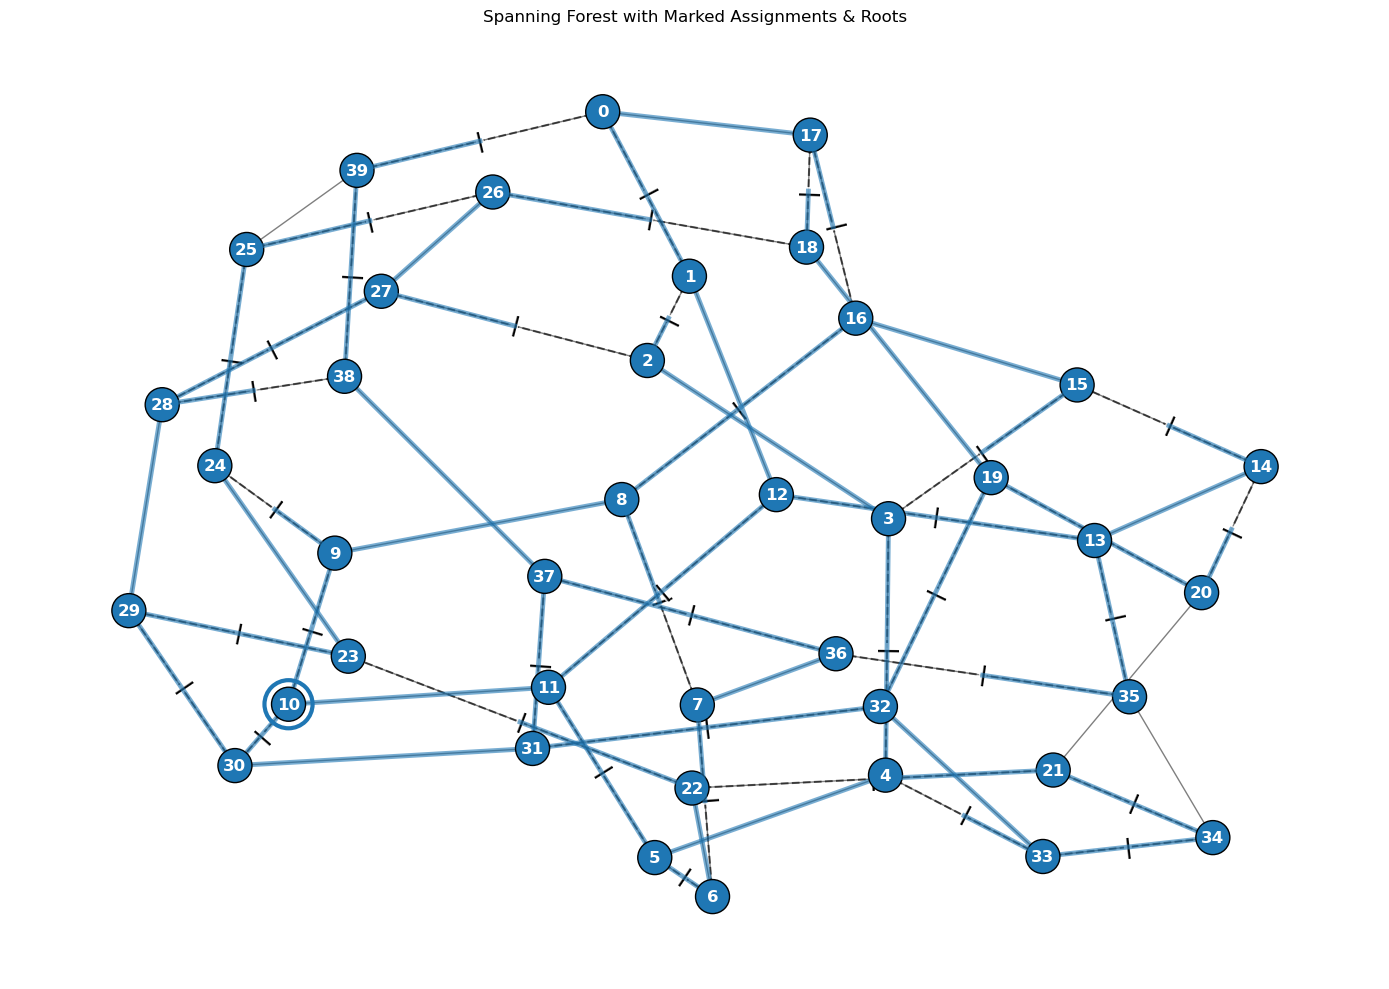

Stats for 40-cat (p=0.05): {0: 0.3309591715344609, 1: 0.3702726473175022, 2: 0.20235789345249897, 3: 0.0720230197101184, 4: 0.01951693178987397, 5: 0.004056918876874037, 6: 0.0007117401538375504, 7: 9.150944835054219e-05, 8: 1.0167716483393576e-05}


In [15]:
import networkx as nx

def extract_forest_and_matches(
    G: nx.Graph,
    G_exp: nx.Graph,
    F: nx.Graph,
    markings: dict[tuple[int, int], int]
) -> tuple[nx.Graph, dict[int, list[tuple[int, int]]]]:

    # 1. Initialize the unexpanded forest
    forest = nx.Graph()
    forest.add_nodes_from(G.nodes())

    # Initialize matches mapping
    matches = {n: [] for n in G.nodes()}

    # Helper to match your exact marking tuple keys (handles undirected edge flips)
    def get_marking_key(u, v):
        if (u, v) in markings: return (u, v)
        if (v, u) in markings: return (v, u)
        return (u, v)

    visited_expanded_edges = set()

    # 2. Trace the paths in G_exp to see what survived in F
    for u in G.nodes():
        for nxt in G_exp.neighbors(u):
            # Sort to avoid double-processing edges
            edge_id = tuple(sorted((u, nxt)))
            if edge_id in visited_expanded_edges:
                continue

            path = [u, nxt]
            visited_expanded_edges.add(edge_id)
            curr = nxt

            # Trace the chain of degree-2 added nodes until hitting another original node
            while curr not in G.nodes():
                neighbors = list(G_exp.neighbors(curr))
                # The next node in the path is the one we didn't just come from
                next_node = neighbors[0] if neighbors[0] != path[-2] else neighbors[1]

                next_edge_id = tuple(sorted((curr, next_node)))
                visited_expanded_edges.add(next_edge_id)

                path.append(next_node)
                curr = next_node

            v = path[-1]
            edge_key = get_marking_key(u, v)

            # 3. Check if the entire path is present in the forest F
            path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
            is_intact = all(F.has_edge(x, y) for x, y in path_edges)

            if is_intact:
                # The whole path survived, so the original edge exists in the unexpanded forest
                forest.add_edge(u, v)
            else:
                # The path is broken. Check if 'u' or 'v' have partial stubs reaching into F.
                # If they do, map that node to this marking.
                if F.has_edge(u, path[1]):
                    matches[u].append(edge_key)
                if F.has_edge(path[-2], v):
                    matches[v].append(edge_key)

    # Clean up matches so we only return nodes that actually have stubs
    matches = {k: v for k, v in matches.items() if len(v) > 0}

    return forest, matches

F_exp, m = extract_forest_and_matches(grf, G, F, M)
roots = find_min_height_roots(F_exp)
draw_spanning_forest_solution(grf, F_exp, M, m, roots)

from spidercat.benchmark import benchmark_solution

new2 = benchmark_solution(grf, F_exp, M, m, roots, num_samples=10_000_000)


In [20]:

key_max = max(max(og.keys()), max(new2.keys()))

for k in range(key_max + 1):
    print(f"Key: {k} -> OG: {og.get(k, 0):.3%}; \t NEW1: {new2.get(k, 0):.3%}")

# print(og)
# print(new2)
# print(new3)

Key: 0 -> OG: 35.047%; 	 NEW1: 33.096%
Key: 1 -> OG: 37.143%; 	 NEW1: 37.027%
Key: 2 -> OG: 19.370%; 	 NEW1: 20.236%
Key: 3 -> OG: 6.448%; 	 NEW1: 7.202%
Key: 4 -> OG: 1.623%; 	 NEW1: 1.952%
Key: 5 -> OG: 0.300%; 	 NEW1: 0.406%
Key: 6 -> OG: 0.060%; 	 NEW1: 0.071%
Key: 7 -> OG: 0.006%; 	 NEW1: 0.009%
Key: 8 -> OG: 0.000%; 	 NEW1: 0.001%
Key: 9 -> OG: 0.001%; 	 NEW1: 0.000%


In [17]:
roots[5] = 38
roots[0] = 28
new3 = benchmark_solution(grf, F_exp, M, m, roots, num_samples=10_000_000)

ValueError: The two qubit gate CX was applied to a target pair with the same target (40) twice. Gates can't interact targets with themselves.

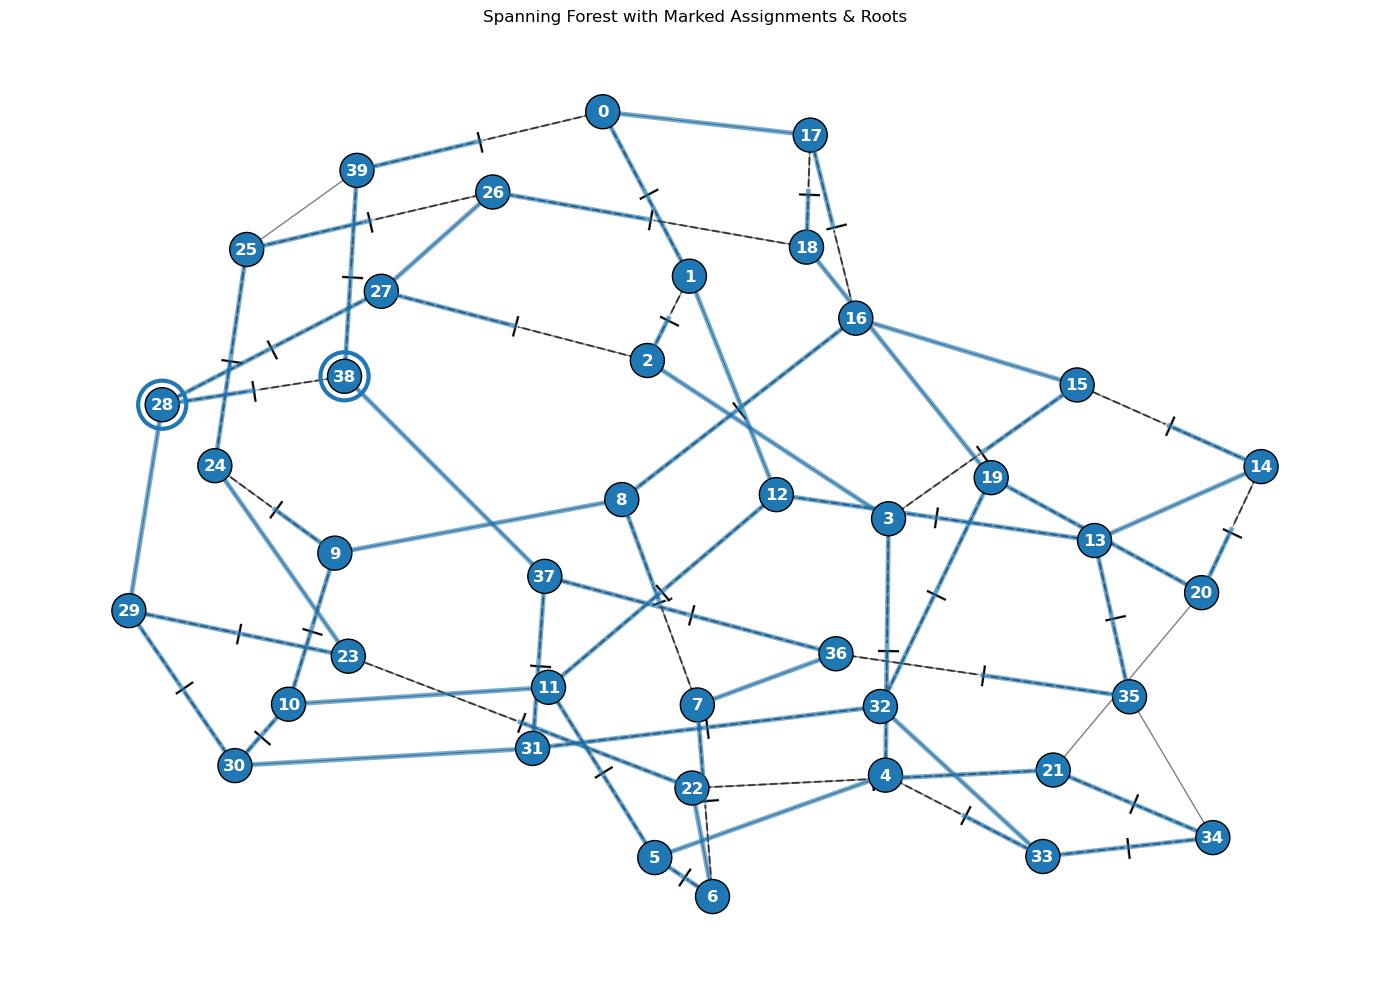

In [18]:
draw_spanning_forest_solution(grf, F_exp, M, m, roots)

In [21]:
get_forest_max_diameter(F_exp)

5